In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("LHCb")

# Load MC dataset
df = pd.read_csv("D:/b_meson_analysis/charm_baryon_analysis/data/lc_candidates.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200000, 11)


,Lc_M,Lc_PT,log_IPCHI2,log_FDCHI2,p_PROBNNp,K_PROBNNk,pi_PROBNNpi,Lc_ENDVERTEX_CHI2,m2_pK,m2_Kpi,label
0,2288.983571,1048.968617,-1.168729,2.766896,0.892354,0.879311,0.626263,0.010592,5.291094e+06,2.263507e+06,1
1,2285.808678,3444.679082,-0.368953,2.135680,0.930687,0.842926,0.841143,1.748202,2.745130e+06,1.621234e+06,1
2,2289.738443,645.716545,0.396574,3.456495,0.689033,0.717506,0.576238,0.294264,3.668552e+06,8.101412e+05,1
3,2294.115149,4606.883233,-1.094678,2.203933,0.592770,0.775932,0.611527,0.007864,3.607732e+06,4.874366e+05,1
4,2285.329233,279.281138,-1.338028,2.794161,0.651699,0.810977,0.819648,2.440047,5.927301e+06,1.697977e+06,1


# Particle Identification (PID) in LHCb / Belle II

Particle identification (PID) variables such as PROBNNp, PROBNNk, and PROBNNpi
are outputs of multivariate classifiers trained on detector information 
(RICH detectors, calorimeters, tracking).

These variables represent probabilities that a given track corresponds to:
- Proton (PROBNNp)
- Kaon (PROBNNk)
- Pion (PROBNNpi)

They approximately satisfy:
PROBNNp + PROBNNk + PROBNNpi ≈ 1

## Why PID is critical for Λc+ → pK-π+

The dominant background arises from:
- π misidentified as proton
- random combinatorial tracks

Since protons are rare in background, requiring high PROBNNp is extremely powerful.

This is standard in Λc+ analyses:
(see Belle measurement: arXiv:1312.7826)

## Strategy

Apply cuts:
- p_PROBNNp > threshold
- K_PROBNNk > threshold
- pi_PROBNNpi > threshold

to suppress combinatorial background while retaining signal.

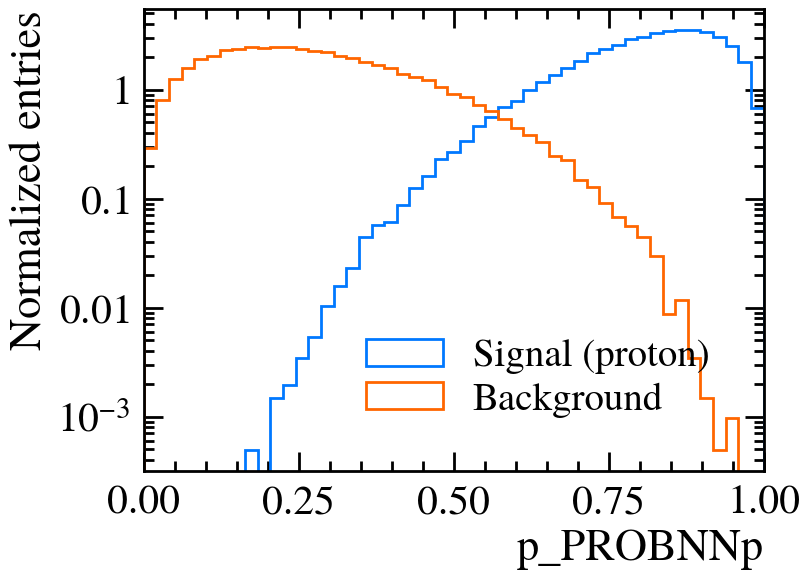

In [2]:
plt.figure(figsize=(8,6))

bins = np.linspace(0, 1, 50)

# Signal vs background
plt.hist(df[df["label"]==1]["p_PROBNNp"], bins=bins, histtype="step",
         label="Signal (proton)", density=True)

plt.hist(df[df["label"]==0]["p_PROBNNp"], bins=bins, histtype="step",
         label="Background", density=True)

plt.yscale("log")
plt.xlabel("p_PROBNNp")
plt.ylabel("Normalized entries")
plt.legend()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/pid_proton.png")
plt.show()

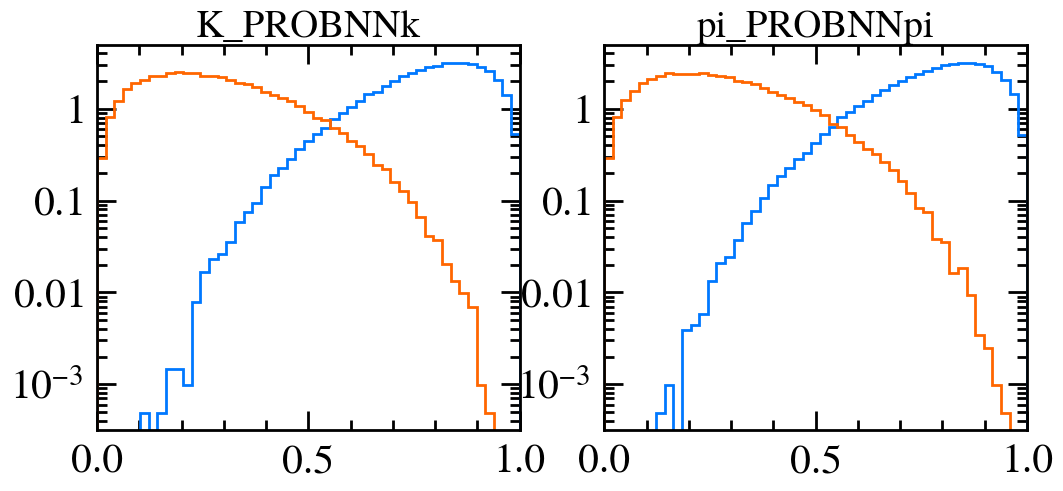

In [3]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

bins = np.linspace(0,1,50)

# Kaon
axs[0].hist(df[df["label"]==1]["K_PROBNNk"], bins=bins,
            histtype="step", label="Signal", density=True)
axs[0].hist(df[df["label"]==0]["K_PROBNNk"], bins=bins,
            histtype="step", label="Background", density=True)

axs[0].set_yscale("log")
axs[0].set_title("K_PROBNNk")

# Pion
axs[1].hist(df[df["label"]==1]["pi_PROBNNpi"], bins=bins,
            histtype="step", density=True)
axs[1].hist(df[df["label"]==0]["pi_PROBNNpi"], bins=bins,
            histtype="step", density=True)

axs[1].set_yscale("log")
axs[1].set_title("pi_PROBNNpi")

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/pid_kaon_pion.png")
plt.show()

In [4]:
thresholds = np.linspace(0.1, 0.9, 50)

eff_sig = []
rej_bkg = []

for t in thresholds:
    df_cut = df[
        (df["p_PROBNNp"] > t)
    ]

    sig_total = len(df[df["label"]==1])
    bkg_total = len(df[df["label"]==0])

    sig_pass = len(df_cut[df_cut["label"]==1])
    bkg_pass = len(df_cut[df_cut["label"]==0])

    eff_sig.append(sig_pass / sig_total)
    rej_bkg.append(1 - (bkg_pass / bkg_total))

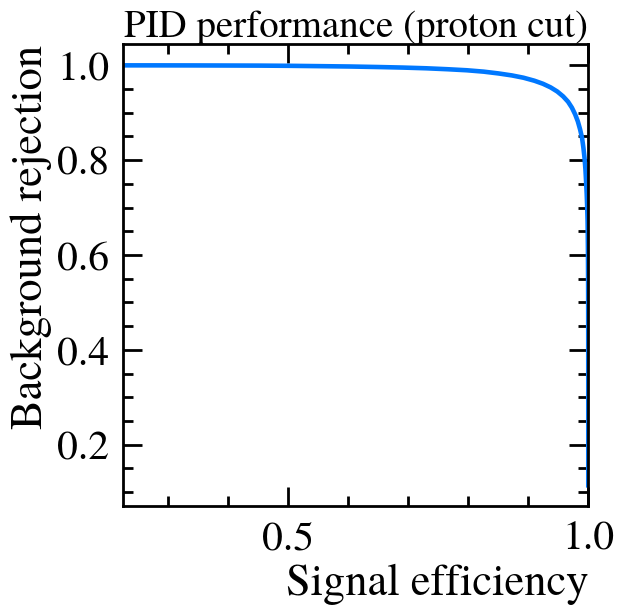

In [5]:
plt.figure(figsize=(6,6))

plt.plot(eff_sig, rej_bkg)

plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection")
plt.title("PID performance (proton cut)")

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/pid_roc.png")
plt.show()

In [6]:
df_pid = df[
    (df["p_PROBNNp"] > 0.5) &
    (df["K_PROBNNk"] > 0.3) &
    (df["pi_PROBNNpi"] > 0.3)
]

print("After PID cuts:", df_pid.shape)

After PID cuts: (99641, 11)


In [7]:
df_sel = df_pid[df_pid["Lc_ENDVERTEX_CHI2"] < 5]

print("After vertex cut:", df_sel.shape)

After vertex cut: (96184, 11)


In [8]:
def count(df):
    sig = len(df[df["label"]==1])
    bkg = len(df[df["label"]==0])
    eff = sig / len(df[df["label"]==1])
    return sig, bkg, eff

rows = []

rows.append(["No cuts", *count(df)])
rows.append(["After PID", *count(df_pid)])
rows.append(["PID + vertex", *count(df_sel)])

summary = pd.DataFrame(rows, columns=[
    "Cut", "N_signal", "N_bkg", "Signal_efficiency"
])

print(summary)

summary.to_csv("D:/b_meson_analysis/charm_baryon_analysis/results/preselection_summary.csv", index=False)

            Cut  N_signal   N_bkg  Signal_efficiency
0       No cuts    100000  100000                1.0
1     After PID     97797    1844                1.0
2  PID + vertex     95278     906                1.0


# Why PID is especially powerful for baryons

Unlike mesons, baryons contain a proton in the final state.

Protons are rare in combinatorial background, so requiring:
p_PROBNNp > 0.5 strongly suppresses background.

This makes Λc+ reconstruction cleaner than many meson channels.

This is a key advantage used in Belle and LHCb charm baryon analyses.